Define file locations and import scripts

In [1]:
import pandas as pd
import pyreadstat
import shutil
from gcsfs import GCSFileSystem
import tempfile 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

print('Run in Google Cloud SDK shell:')
print('gcloud auth application-default login')

Run in Google Cloud SDK shell:
gcloud auth application-default login


In [3]:
fs = GCSFileSystem(project='clgx-gis-app-dev-06e3', token='google_default')

In [4]:
#enter path to locally synced one drive
od_path = r"C:\Users\joglick\OneDrive - CoreLogic Solutions, LLC"

#"C:\Users\joglick\OneDrive - CoreLogic Solutions, LLC\Location Science - Crime Risk\Carrier Evals"
eval_path = fr'{od_path}\Location Science - Crime Risk\Carrier Evals'

#Path to GCS buckets
gcs_path = "gs://geospatial-projects/location_inc"


In [5]:
def read_sav_from_gcs(gcs_path: str, fs: GCSFileSystem) -> pd.DataFrame:
    with fs.open(gcs_path, "rb") as gcs_file:
        # Write the content to a temporary file
        with tempfile.NamedTemporaryFile(delete=False) as temp_file:
            temp_file.write(gcs_file.read())
            temp_file.flush()
            temp_file.close()

            # Read the .sav file using pyreadstat
            df, meta = pyreadstat.read_sav(temp_file.name)
    
    return df, meta

Import carrier evalauations

### Common terms used in carrier evalauations:

* Earned Exposure: Corresponds to one policy in one year. Decimal values represent partial coverage. Rare negative values are an artifact of the carrier's accounting should be excluded from analaysis
* Premium: The policy premium paid by the insured for the corresponding earned exposure (When earned expsore = 1 premium is the annual premium)
* Claims: The count of claims paid by the insurance carrier for given loss perils  (e.g. theft claims represent all claims where the cause of loss is theft)
* Losses: The $ amount paid out by the carrier for given loss perils (e.g. theft loss is the amount paid by the carrier where cause of loss is theft)
* Crime Loss Types: 
  * Theft and Vandalism are the common loss types associated with property insurance
  * Losses associated with violent crime can take the form of liability losses (e.g. a property owner is sued after a violent crime on their property). We recieve these loses more rarely in carrier evals but they can be very high $ amounts (not included in the evals below).

In [7]:
eval1 = pd.read_excel(fr"{eval_path}\Copy of OregonMutual_CrimeRisk.xlsx",converters={'CRIME_CensusBlock':str,'Zip':str})
eval2 = pd.read_excel(fr"{eval_path}\Copy of Guard_CrimeRisk.xlsx",converters={'CLCrime_CensusBlock':str,'Zip':str})
#eval 3 doesn't have loss by peril
#eval3 = pd.read_excel(fr"{eval_path}\Copy of Seneca_CrimeRisk.xlsx",converters={'CRIME_CensusBlock':str,'Zip':str})

In [ ]:
#function for importing eval chunks from Hanover and Travellers
def import_chunk(file):
    eval_chunk = pd.read_csv(file,converters={'censusblock_2020':str,'zip':str})
    return eval_chunk.groupby(['censusblock_2020','carrier','total_crime_index'])[
    ['earnedexposure','premium','loss','claim']].sum().reset_index()

In [35]:
file_root = fr"{eval_path}\risksuite_Adhoc_JG_CrimeRiskRequest_TravHan_0000000000"

eval4 = import_chunk(f'{file_root}00.csv')

In [36]:
for i in range(1,10):
    eval4 = pd.concat([eval4,import_chunk(f'{file_root}0{i}.csv')])

In [37]:
for i in range(10,15):
    eval4 = pd.concat([eval4,import_chunk(f'{file_root}{i}.csv')])

In [38]:
#standardize column name
eval4.rename({
    'censusblock_2020':'CRIME_CensusBlock','carrier':'Carrier', 'loss':'Crime_Loss',
    'claim':'Crime_Claims','earnedexposure':'Earned_Exposures','premium':'Premium',
    'total_crime_index':'CLCrime_TotalCrimeIndex'
    },axis=1,inplace=True)

In [15]:
#standardize column name
eval2['Crime_Claims'] = (eval2['Property Theft Claims']+eval2['Property Vandalism Claims']).fillna(value=0)
eval2['Crime_Loss'] = (eval2['Property Theft Loss']+eval2['Property Vandalism Loss']).fillna(value=0)
eval1['Crime_Claims'] = eval1['Theft Claims'].fillna(value=0)
eval1['Crime_Loss'] = eval1['Theft Losses'].fillna(value=0)
eval2.rename({'CLCrime_CensusBlock':'CRIME_CensusBlock'},axis=1,inplace=True)


In [39]:
eval1['Carrier'] = "OregonMutal"
eval2['Carrier'] = "Guard"
#eval3['Carrier'] = "Seneca"

eval_df = pd.concat([eval1,eval2,eval4]).reset_index(drop=True)

In [40]:
eval_df[['CRIME_CensusBlock','Carrier','Crime_Loss','Crime_Claims','Earned_Exposures','CLCrime_TotalCrimeIndex']].count()

CRIME_CensusBlock          3390107
Carrier                    3408855
Crime_Loss                 3408855
Crime_Claims               3408855
Earned_Exposures           3408855
CLCrime_TotalCrimeIndex    3390107
dtype: int64

In [41]:
eval_df['Carrier'].value_counts()

Carrier
TRAV           2480028
Guard           638020
HANO            190239
OregonMutal     100568
Name: count, dtype: int64

Join CBSA codes and names

In [18]:
#get cbsa by census tract from NeighborhoodScout
nhood_df, meta = read_sav_from_gcs(f'{gcs_path}/ns4/2025q4/neighborhoods_ns4.sav',fs)
#get cbsa names
cbsa_df, meta = read_sav_from_gcs(f'{gcs_path}/ns4/2025q4/metros_ns4.sav',fs)
#join cbsa names to census tracts
ct_cbsa = nhood_df[['ct_key','cbsa5']].join(cbsa_df.set_index('cbsa5')['cbsa_title'],on='cbsa5')

In [42]:
#check for dropped leading zero in code
eval_df.loc[eval_df['CRIME_CensusBlock'].str.len()==14,'CRIME_CensusBlock'] = '0'+eval_df['CRIME_CensusBlock']
#join cbsa names to eval
eval_df['ct_key'] = eval_df['CRIME_CensusBlock'].str[:11]
eval_df = eval_df.join(ct_cbsa.set_index('ct_key'),on='ct_key')


Join agency level crime reporting

In [21]:
#get latest block to place table
blocks, meta = read_sav_from_gcs(f"{gcs_path}/demographic/population_estimates/2024/block_place.sav", fs)
 
#get latest agency assignments by place
crosswalk, meta = read_sav_from_gcs(f"{gcs_path}/crime/2024/ucr_crosswalk.sav", fs)
muni_agency = crosswalk[crosswalk['popest_geo']>0].groupby('muni_key')['akey'].first()
#determine which place codes map to crime muni
blocks['muni_key']=blocks['STATE']+blocks['PLACE_CDP']
blocks = blocks.join(muni_agency,on='muni_key')

#match to COUNTY subdivision if not already matched
blocks.loc[blocks['akey'].isna(),'muni_key']=blocks['STATE']+blocks['COUSUB']
blocks = blocks.drop('akey',axis=1).join(muni_agency,on='muni_key')

#match to balance of COUNTY if not already matched
blocks.loc[blocks['akey'].isna(),'muni_key']=blocks['STATE']+'99'+blocks['COUNTY_2020']
#recode small areas lacking coverage
blocks['muni_key'] = blocks['muni_key'].replace({'3499013':'3446380'})
blocks = blocks.drop('akey',axis=1).join(muni_agency,on='muni_key')

#get latest agency data
muni_df, meta = read_sav_from_gcs(f'{gcs_path}/crime/2024/muni_data.sav',fs)

#keep crime rates, job counts, pop, seasonal
crimes = ['violent','murder','rape','robbery','assault','property','burglary','larceny','mvt']
primary_crimes = list(set(crimes)-set(['violent','property']))

muni_rates = [f'{i}_pt_m' for i in crimes]
agency_rates = muni_df[['akey','population_m','C000','seasonal_pct']+muni_rates].drop_duplicates(subset='akey')


In [ ]:
#list Houston area agcencies for exploration
crosswalk[(crosswalk['msa_name']=='Houston-The Woodlands-Sugar Land, TX')&(
    crosswalk['popest_agency']>0
)].groupby(['muni_key','geo_name','akey'])[['popest_agency']].max(

).sort_values(by='popest_agency',ascending=False).to_clipboard()
# or use msa_name = 'Chicago-Naperville-Elgin, IL-IN-WI'

In [43]:
#join agency by block
eval_df = eval_df.join(blocks.set_index('GEOID20')['akey'],on='CRIME_CensusBlock')
#join rates by agency
eval_df = eval_df.join(agency_rates.set_index('akey'),on='akey')

In [44]:
eval_df[
    ['CRIME_CensusBlock','Carrier','Crime_Loss','Crime_Claims','Earned_Exposures','CLCrime_TotalCrimeIndex','violent_pt_m']
    ].count()

CRIME_CensusBlock          3390107
Carrier                    3408855
Crime_Loss                 3408855
Crime_Claims               3408855
Earned_Exposures           3408855
CLCrime_TotalCrimeIndex    3390107
violent_pt_m               3390105
dtype: int64

In [45]:
#weight crimes by severity
#join us crime totals
us_df, meta = read_sav_from_gcs(f"{gcs_path}/crime/2024/ucr_us.sav", fs)

for i in crimes:
    eval_df[f'{i}_pt_u'] = us_df[f'ucr_{i}_rate_u'][0]
#each primary crime type contributes 1/7 to total
eval_df.loc[eval_df[['violent_pt_m','property_pt_m']].notna().any(axis=1),'total_rel_m']=0
for i in primary_crimes:
    eval_df['total_rel_m'] = eval_df['total_rel_m'] + eval_df[f'{i}_pt_m']/eval_df[f'{i}_pt_u']/7
eval_df['wtotal_pt_m'] = eval_df['total_rel_m'] * eval_df[['violent_pt_u','property_pt_u']].sum(axis=1)    

#each property crime contributes 1/3 to total
property_crimes = ['larceny','burglary','mvt']
eval_df.loc[eval_df[['violent_pt_m','property_pt_m']].notna().any(axis=1),'prop_rel_m']=0
for i in property_crimes:
    eval_df['prop_rel_m'] = eval_df['prop_rel_m'] + eval_df[f'{i}_pt_m']/eval_df[f'{i}_pt_u']/3
eval_df['wprop_pt_m'] = eval_df['prop_rel_m'] * eval_df['property_pt_u'] 

eval_df['total_pt_m'] = eval_df['property_pt_m']+eval_df['violent_pt_m']

In [46]:
#include daytime pop (employment) in denominator
eval_df['wprop_ptd_m'] = eval_df['wprop_pt_m']
eval_df.loc[eval_df[['population_m','C000']].sum(axis=1)>0,
               'wprop_ptd_m'] = eval_df['wprop_pt_m'] * eval_df['population_m'] / eval_df[['population_m','C000']].sum(axis=1) 

#daytime adjust weighted total
eval_df['wtotal_ptd_m'] = eval_df['wtotal_pt_m']
eval_df.loc[eval_df[['population_m','C000']].sum(axis=1)>0,
               'wtotal_ptd_m'] = eval_df['wtotal_pt_m'] * eval_df['population_m'] / eval_df[['population_m','C000']].sum(axis=1) 

#seasonal population
eval_df['seasonal_pop'] = eval_df['seasonal_pct'] * eval_df['population_m']/100

#seaonal adjust weighted total
eval_df['wtotal_pts_m'] = eval_df['wtotal_pt_m']
eval_df.loc[eval_df[['population_m','seasonal_pop']].sum(axis=1)>0,
               'wtotal_pts_m'] = eval_df['wtotal_pt_m'] * eval_df['population_m'] / eval_df[['population_m','seasonal_pop']].sum(axis=1) 

#seasonal adjust daytime weighted total
eval_df['wtotal_ptds_m'] = eval_df['wtotal_ptd_m']
eval_df.loc[eval_df[['population_m','seasonal_pop']].sum(axis=1)>0,
               'wtotal_ptds_m'] = eval_df['wtotal_ptd_m'] * eval_df['population_m'] / eval_df[['population_m','seasonal_pop']].sum(axis=1)

Save/Load combined dataframe

In [47]:
eval_df.to_parquet(f'{eval_path}/evals.parquet',engine='fastparquet')
#eval_df = pd.read_parquet(f'{eval_path}/evals.parquet',engine='fastparquet')

In [89]:
print(fr'{eval_path}/evals.parquet')

C:\Users\joglick\OneDrive - CoreLogic Solutions, LLC\Location Science - Crime Risk\Carrier Evals/evals.parquet


Check Distribution by CBSA

In [48]:
#check for CBSA with most crime reporting
eval_df.groupby(['cbsa5','cbsa_title','Carrier'])[['Earned_Exposures','Crime_Claims']].sum().sort_values(by='Crime_Claims',ascending=False).head(20)

,,,Earned_Exposures,Crime_Claims
cbsa5,cbsa_title,Carrier,,
31080,"Los Angeles-Long Beach-Anaheim, CA Metro Area",Guard,50466.972246,555.0
35620,"New York-Newark-Jersey City, NY-NJ Metro Area",Guard,126114.722407,551.0
47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV Metro Area",TRAV,240801.601855,503.0
16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",Guard,18042.377930,484.0
35620,"New York-Newark-Jersey City, NY-NJ Metro Area",TRAV,375537.316324,386.0
12060,"Atlanta-Sandy Springs-Roswell, GA Metro Area",TRAV,196097.588619,383.0
19740,"Denver-Aurora-Centennial, CO Metro Area",TRAV,93597.129107,327.0
41860,"San Francisco-Oakland-Fremont, CA Metro Area",Guard,19624.764270,315.0
42660,"Seattle-Tacoma-Bellevue, WA Metro Area",TRAV,71894.147597,270.0


In [49]:
#select rows with Guard policies and > 0 exposure.
Guard_eval = eval_df[(eval_df['Carrier'] == 'Guard') & (eval_df['Earned_Exposures']>0)].copy()
OM_eval = eval_df[(eval_df['Carrier'] == 'OregonMutal') & (eval_df['Earned_Exposures']>0)].copy()
Trav_eval = eval_df[(eval_df['Carrier'] == 'TRAV') & (eval_df['Earned_Exposures']>0)].copy()
Hano_eval = eval_df[(eval_df['Carrier'] == 'HANO') & (eval_df['Earned_Exposures']>0)].copy()

Lorenze Curves for existing model fit for crime frequency

In [50]:
#create function for curves and gini index
def plot_risk(df, exposure, outcome, risk_score, label):
    #Sort by Predicted Risk
    sort_eval = df.sort_values(by=risk_score, ascending=False)

    #Calculate Cumulative Metrics
    total_exposure = sort_eval[exposure].sum()
    total_outcome = sort_eval[outcome].sum()

    sort_eval['CumExposure'] = sort_eval[exposure].cumsum()
    sort_eval['CumClaims'] = sort_eval[outcome].cumsum()

    # Normalized axis
    sort_eval['PercExposure'] = sort_eval['CumExposure'] / total_exposure
    sort_eval['PercClaims'] = sort_eval['CumClaims'] / total_outcome

    # Add origin
    plot_data = pd.DataFrame({'PercExposure': [0], 'PercClaims': [0]})
    plot_data = pd.concat([plot_data, sort_eval[['PercExposure', 'PercClaims']]], ignore_index=True)
 
    # Calculate Gini Coefficient
    gini_auc = auc(plot_data['PercExposure'], plot_data['PercClaims'])
    gini_coefficient = 2 * gini_auc - 1

    #plot line
    plt.plot(plot_data['PercExposure'], plot_data['PercClaims'], label=f'{label} (Gini={gini_coefficient:.2f})')
 
    

In [66]:
#function for finalizing the plot

def plot_curves(title, df, outcome, outcome_name,Plots_w_names):
    #Plot Freq Lorenz Curves
    plt.figure(figsize=(5, 4))
    var_list = list(Plots_w_names.keys())
    for i in range(0,len(var_list)):
        plot_risk(df,'Earned_Exposures', outcome, var_list[i], Plots_w_names[var_list[i]])
    plt.plot([0, 1], [0, 1], label='Random', color='grey', linestyle='--')
    plt.title(f'Lorenz Curve - {title} ({outcome_name}: {df[outcome].sum().round():,.0f})')
    plt.xlabel('Cumulative % of Exposure by Crime Prediction')
    plt.ylabel(f'Cumulative % of {outcome_name}')
    plt.legend(loc='center right', bbox_to_anchor=(1.75, 0.5))
    plt.minorticks_on()
    plt.grid(True)
    plt.grid(which='minor', color='#CCCCCC', linestyle=':', linewidth=0.5)
    plt.show()

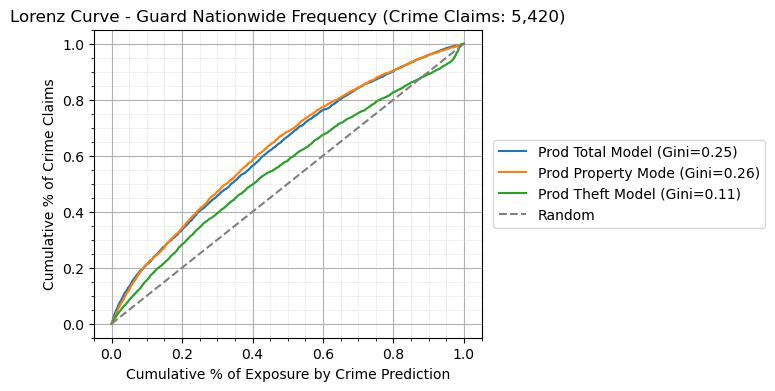

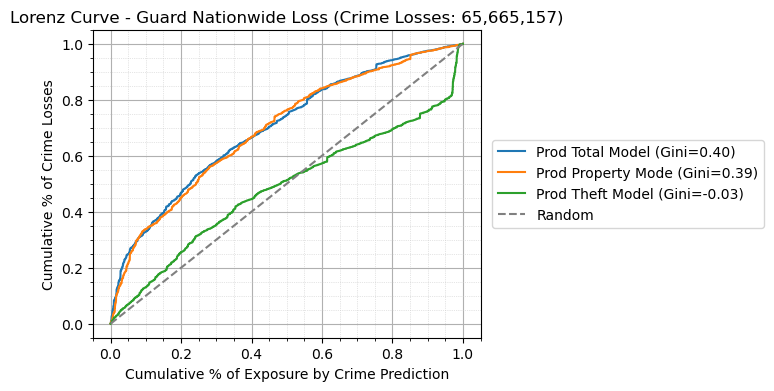

In [67]:
#Plots for Guard Nationwide production models
Plots_w_names = {'CLCrime_TotalCrimeIndex':'Prod Total Model', 'CLCrime_PropertyCrimeIndex':'Prod Property Mode',
              'CLCrime_LarcenyIndex':'Prod Theft Model'}

plot_curves('Guard Nationwide Frequency',Guard_eval,'Crime_Claims','Crime Claims',Plots_w_names )
plot_curves('Guard Nationwide Loss',Guard_eval,'Crime_Loss','Crime Losses',Plots_w_names )

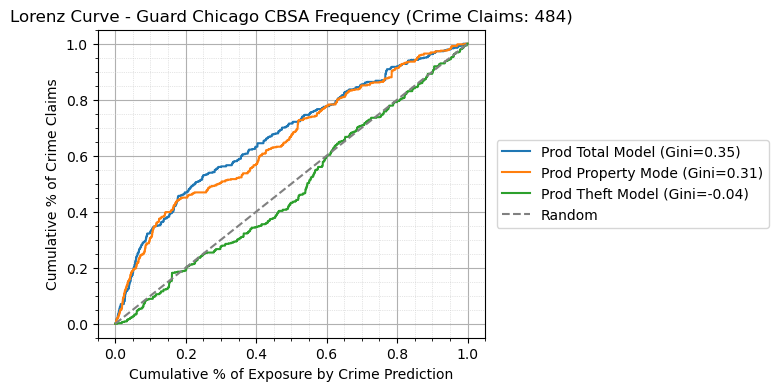

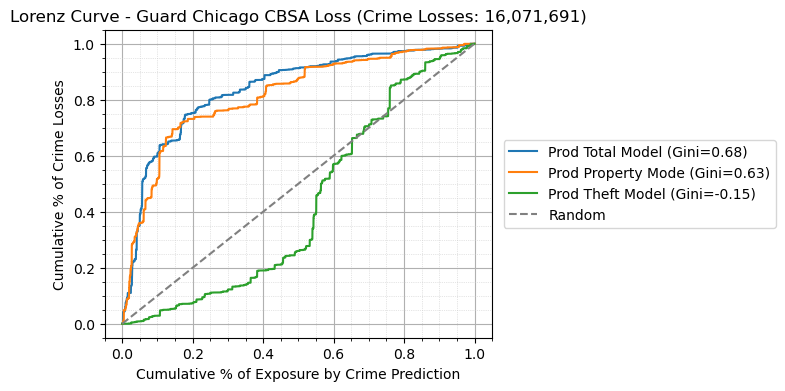

In [68]:
#Plots for Guard Chicago production models
plot_curves('Guard Chicago CBSA Frequency',
             Guard_eval[Guard_eval['cbsa5']=='16980'],'Crime_Claims','Crime Claims',Plots_w_names )
plot_curves('Guard Chicago CBSA Loss',
             Guard_eval[Guard_eval['cbsa5']=='16980'],'Crime_Loss','Crime Losses',Plots_w_names )

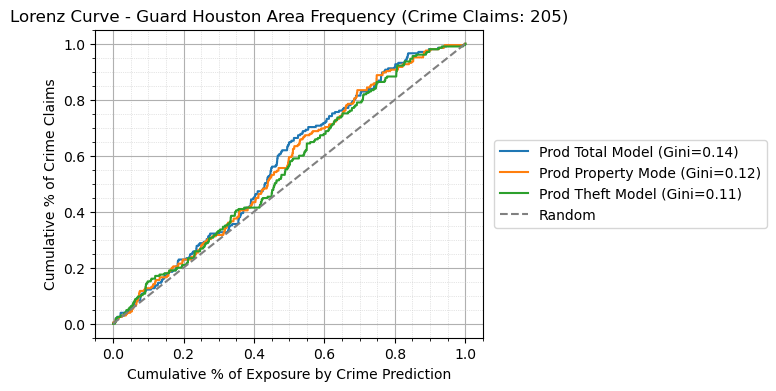

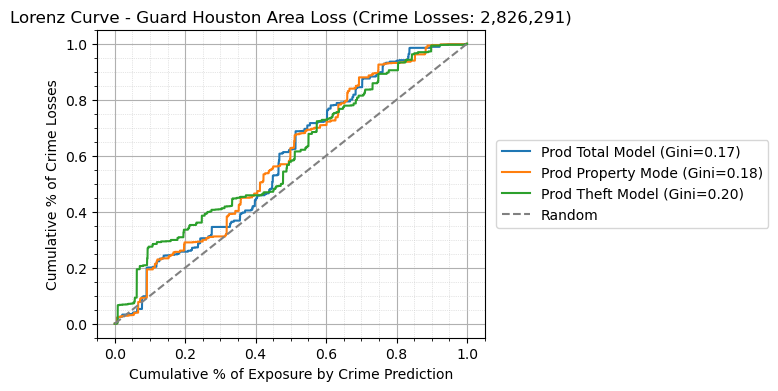

In [69]:
#Plots for Guard Houston models
plot_curves('Guard Houston Area Frequency',
             Guard_eval[Guard_eval['cbsa5']=='26420'],'Crime_Claims','Crime Claims',Plots_w_names )
plot_curves('Guard Houston Area Loss',
             Guard_eval[Guard_eval['cbsa5']=='26420'],'Crime_Loss','Crime Losses',Plots_w_names )


Try predicting with agency reporting alone

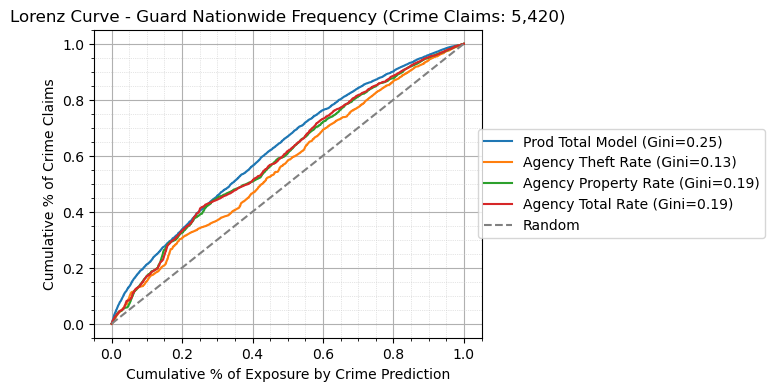

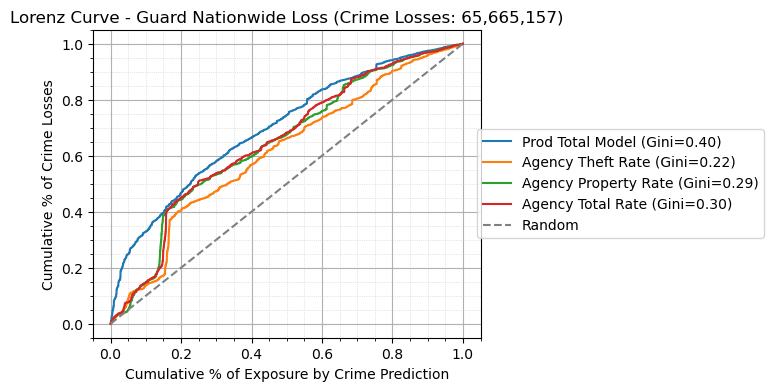

In [70]:
#define index names for plot
agency_plots = {'CLCrime_TotalCrimeIndex':'Prod Total Model', 'larceny_pt_m':'Agency Theft Rate',
              'property_pt_m':'Agency Property Rate','total_pt_m':'Agency Total Rate'}

plot_curves('Guard Nationwide Frequency',Guard_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Nationwide Loss',Guard_eval,'Crime_Loss','Crime Losses',agency_plots)

Severity weighted rates perform significantly better 

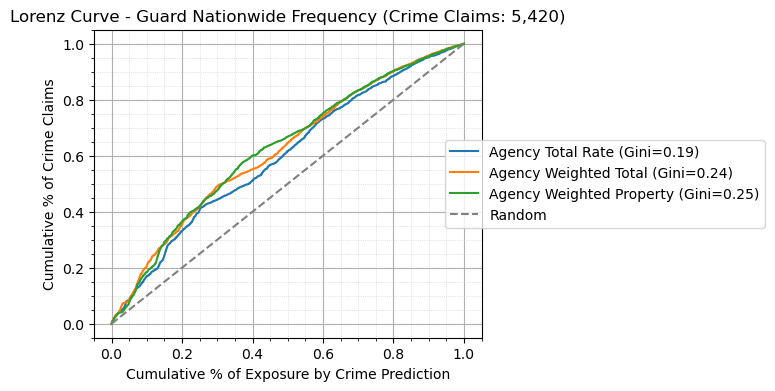

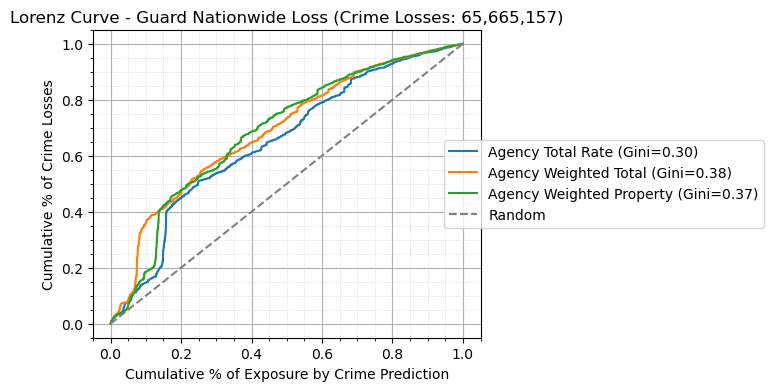

In [71]:
agency_plots = {'total_pt_m':'Agency Total Rate','wtotal_pt_m':"Agency Weighted Total",'wprop_pt_m':'Agency Weighted Property'}

plot_curves('Guard Nationwide Frequency',Guard_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Nationwide Loss',Guard_eval,'Crime_Loss','Crime Losses',agency_plots)

Some evidence for adjusting daytime population 

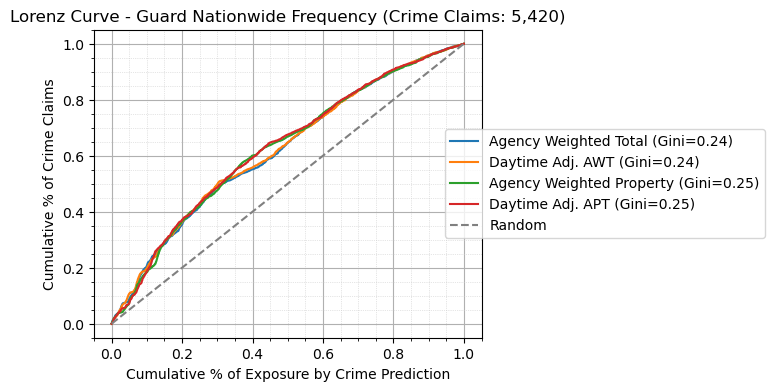

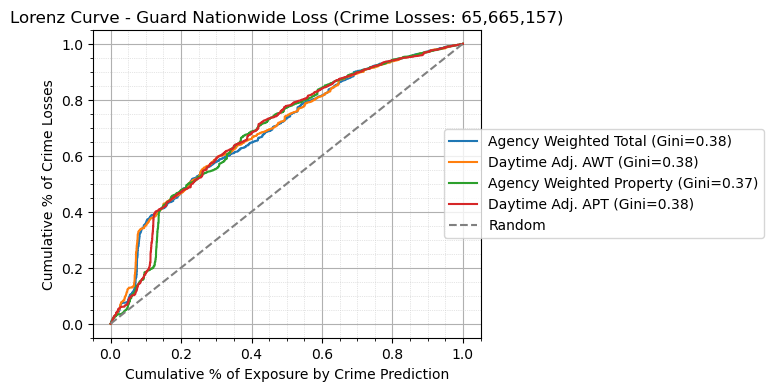

In [72]:


agency_plots = {'wtotal_pt_m':'Agency Weighted Total','wtotal_ptd_m': 'Daytime Adj. AWT',
                'wprop_pt_m':'Agency Weighted Property','wprop_ptd_m': 'Daytime Adj. APT'}


plot_curves('Guard Nationwide Frequency',Guard_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Nationwide Loss',Guard_eval,'Crime_Loss','Crime Losses',agency_plots)

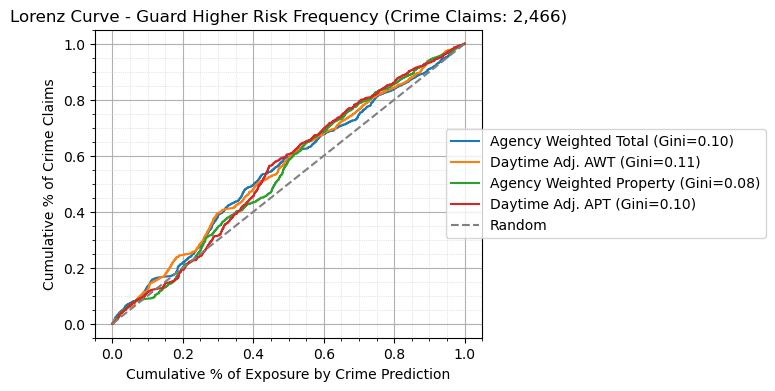

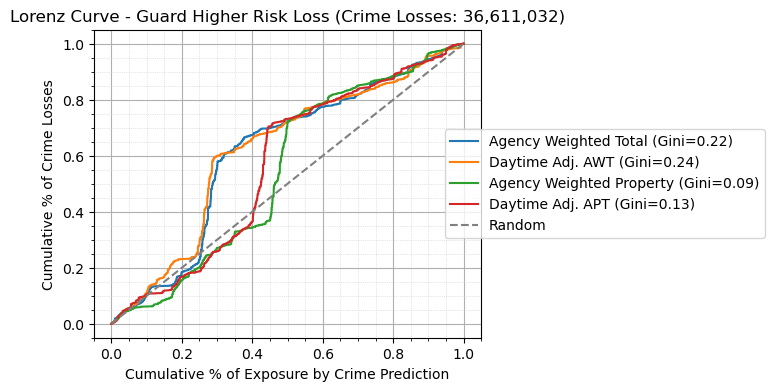

In [73]:
#focus on higher crime rate agencies
plot_curves('Guard Higher Risk Frequency',Guard_eval[Guard_eval['wtotal_pt_m']>30],'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Higher Risk Loss',Guard_eval[Guard_eval['wtotal_pt_m']>30],'Crime_Loss','Crime Losses',agency_plots)

Seasonality - some evidence for adjustment

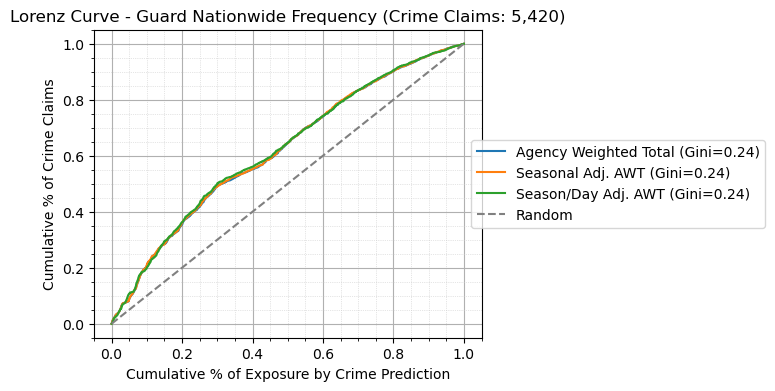

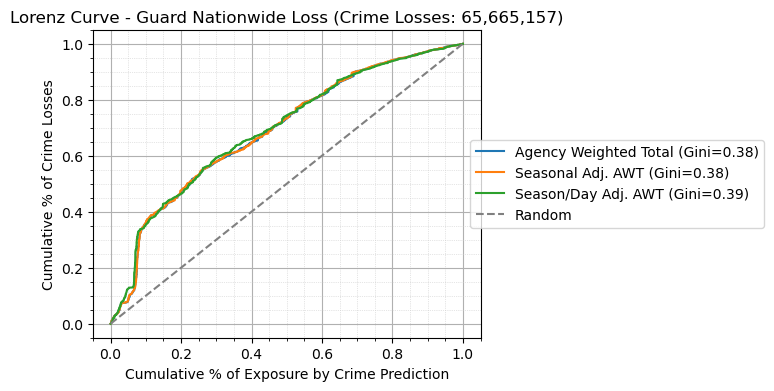

In [74]:
agency_plots = {'wtotal_pt_m':'Agency Weighted Total','wtotal_pts_m': 'Seasonal Adj. AWT',
                'wtotal_ptds_m':'Season/Day Adj. AWT'}

plot_curves('Guard Nationwide Frequency',Guard_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Nationwide Loss',Guard_eval,'Crime_Loss','Crime Losses',agency_plots)


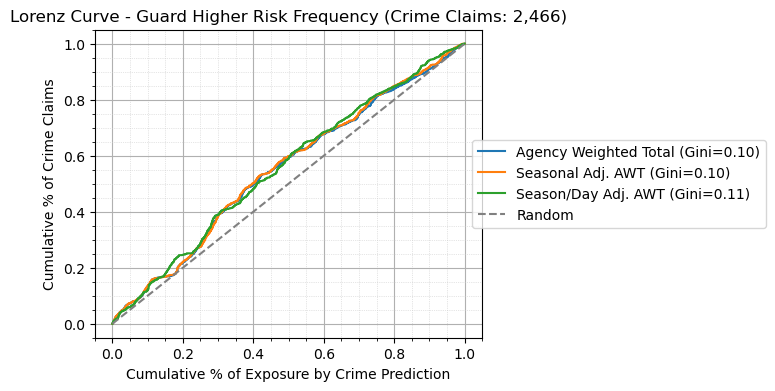

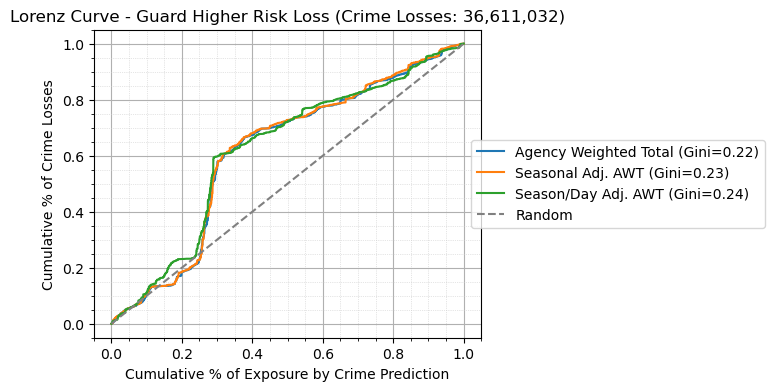

In [75]:
#focus on higher crime rate agencies
plot_curves('Guard Higher Risk Frequency',Guard_eval[Guard_eval['wtotal_pt_m']>30],'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Higher Risk Loss',Guard_eval[Guard_eval['wtotal_pt_m']>30],'Crime_Loss','Crime Losses',agency_plots)

Overall comparison with weights and adjustments

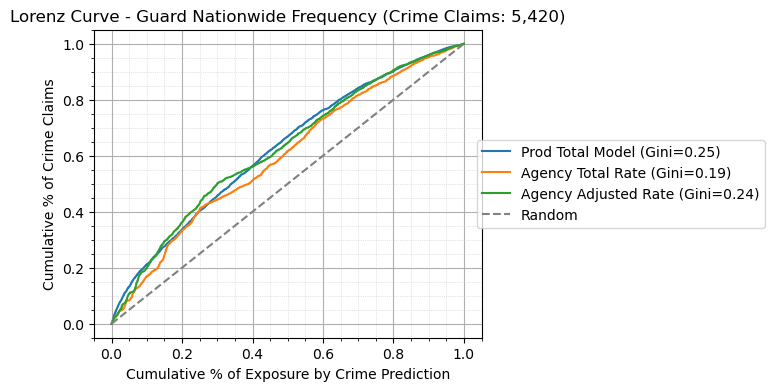

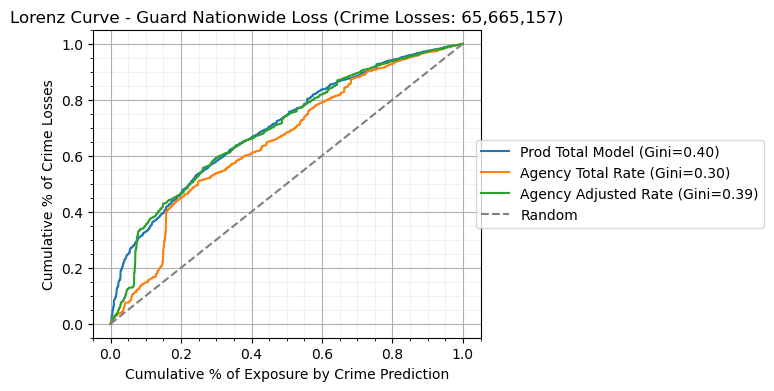

In [76]:
agency_plots = {'CLCrime_TotalCrimeIndex':'Prod Total Model','total_pt_m':'Agency Total Rate',
                'wtotal_ptds_m':'Agency Adjusted Rate'}

plot_curves('Guard Nationwide Frequency',Guard_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Nationwide Loss',Guard_eval,'Crime_Loss','Crime Losses',agency_plots)

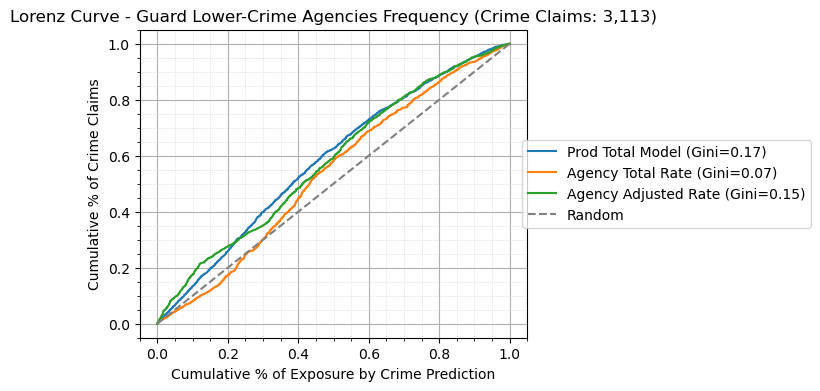

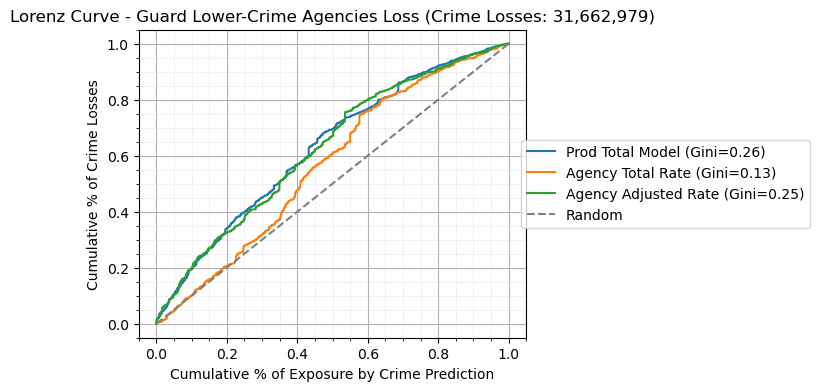

In [91]:
agency_plots = {'CLCrime_TotalCrimeIndex':'Prod Total Model','total_pt_m':'Agency Total Rate',
                'wtotal_ptds_m':'Agency Adjusted Rate'}

plot_curves('Guard Lower-Crime Agencies Frequency',Guard_eval[Guard_eval['total_pt_m']<30],'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Lower-Crime Agencies Loss',Guard_eval[Guard_eval['total_pt_m']<30],'Crime_Loss','Crime Losses',agency_plots)

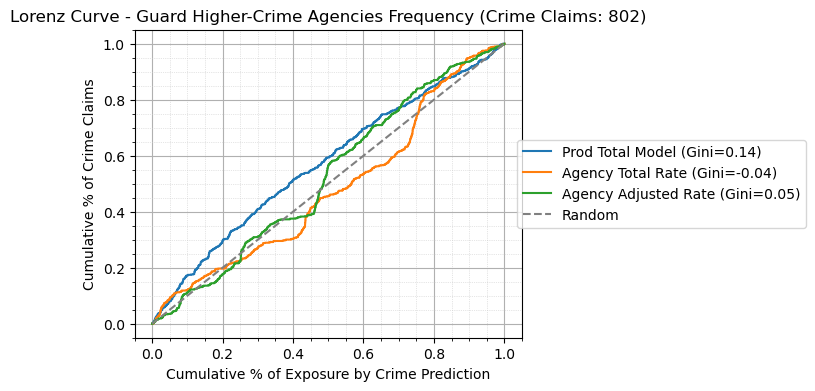

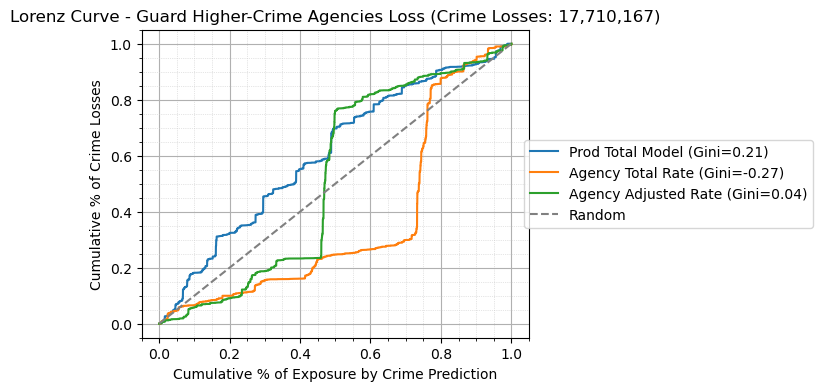

In [92]:
agency_plots = {'CLCrime_TotalCrimeIndex':'Prod Total Model','total_pt_m':'Agency Total Rate',
                'wtotal_ptds_m':'Agency Adjusted Rate'}

plot_curves('Guard Higher-Crime Agencies Frequency',Guard_eval[Guard_eval['CLCrime_TotalCrimeIndex']>60],'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Guard Higher-Crime Agencies Loss',Guard_eval[Guard_eval['CLCrime_TotalCrimeIndex']>60],'Crime_Loss','Crime Losses',agency_plots)

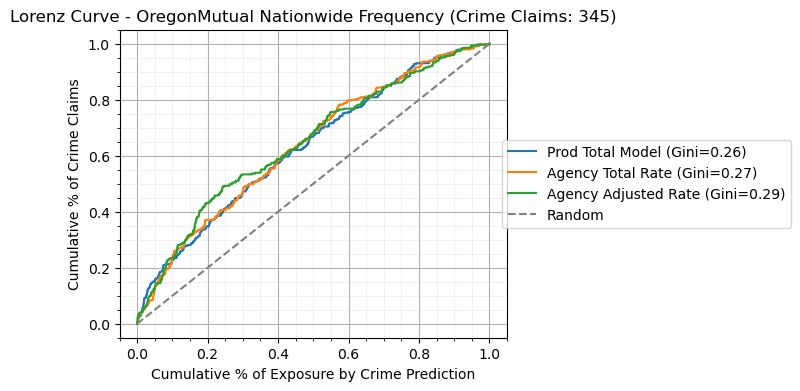

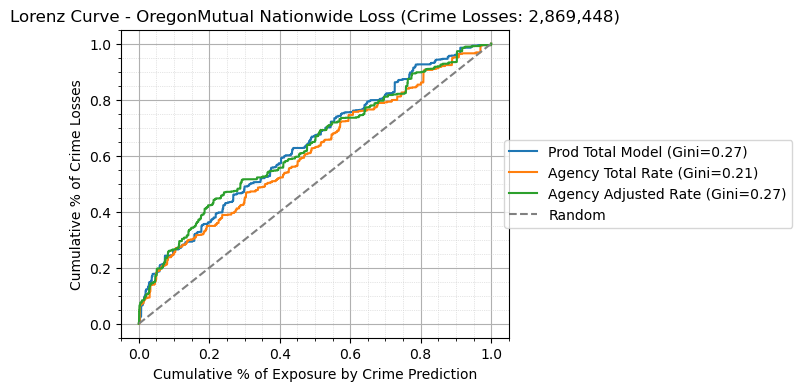

In [77]:
agency_plots = {'CLCrime_TotalCrimeIndex':'Prod Total Model','total_pt_m':'Agency Total Rate',
                'wtotal_ptds_m':'Agency Adjusted Rate'}

plot_curves('OregonMutual Nationwide Frequency',OM_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('OregonMutual Nationwide Loss',OM_eval,'Crime_Loss','Crime Losses',agency_plots) 

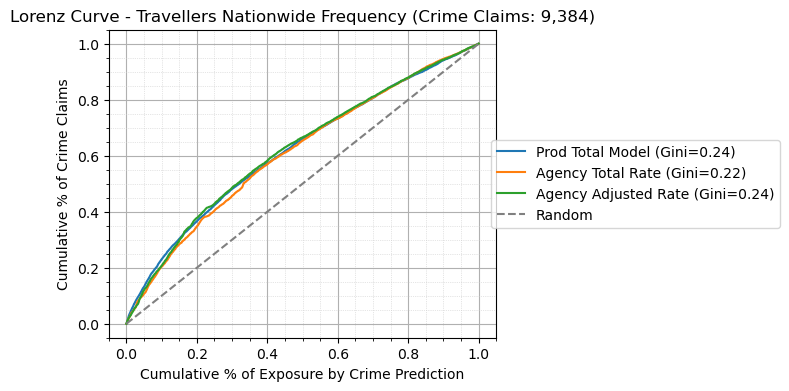

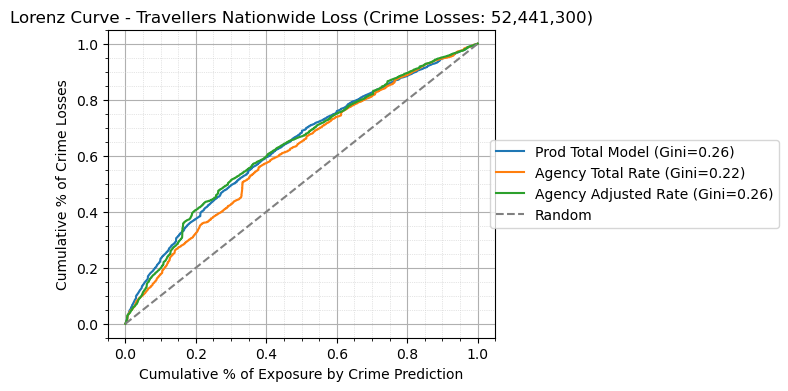

In [78]:
agency_plots = {'CLCrime_TotalCrimeIndex':'Prod Total Model','total_pt_m':'Agency Total Rate',
                'wtotal_ptds_m':'Agency Adjusted Rate'}

plot_curves('Travellers Nationwide Frequency',Trav_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Travellers Nationwide Loss',Trav_eval,'Crime_Loss','Crime Losses',agency_plots) 

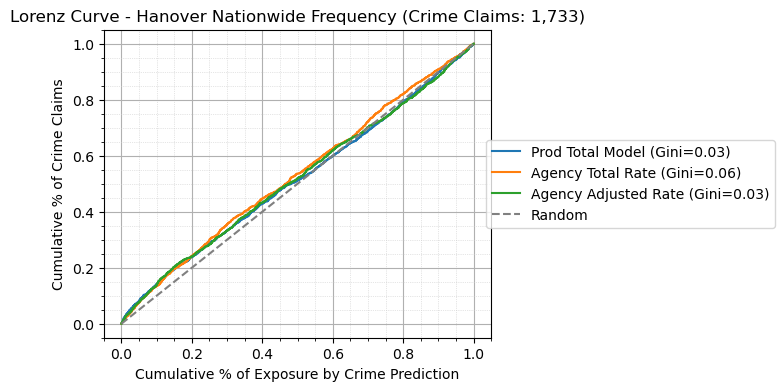

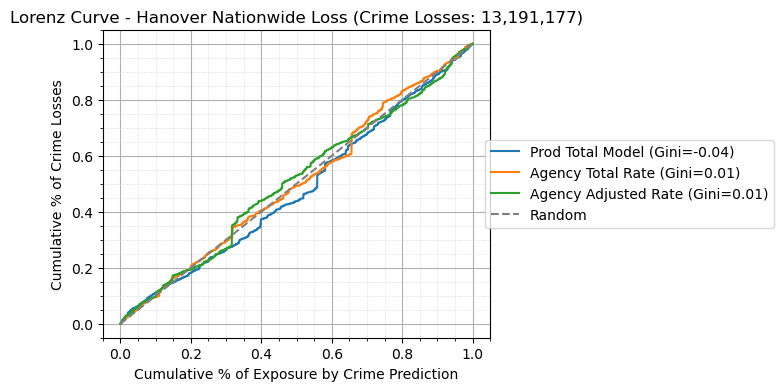

In [79]:
agency_plots = {'CLCrime_TotalCrimeIndex':'Prod Total Model','total_pt_m':'Agency Total Rate',
                'wtotal_ptds_m':'Agency Adjusted Rate'}

plot_curves('Hanover Nationwide Frequency',Hano_eval,'Crime_Claims','Crime Claims',agency_plots)
plot_curves('Hanover Nationwide Loss',Hano_eval,'Crime_Loss','Crime Losses',agency_plots) 

CONCLUSION: agency reporting with weighting and adjustment can perform similar overall to the production model

production model adds significant lift within Chicago CBSA but not Houston CBSA

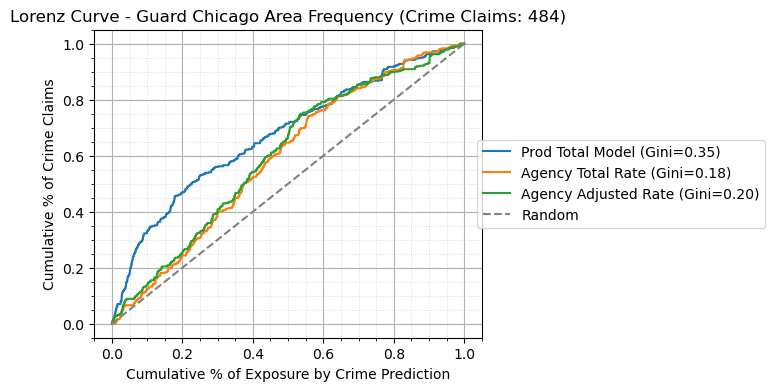

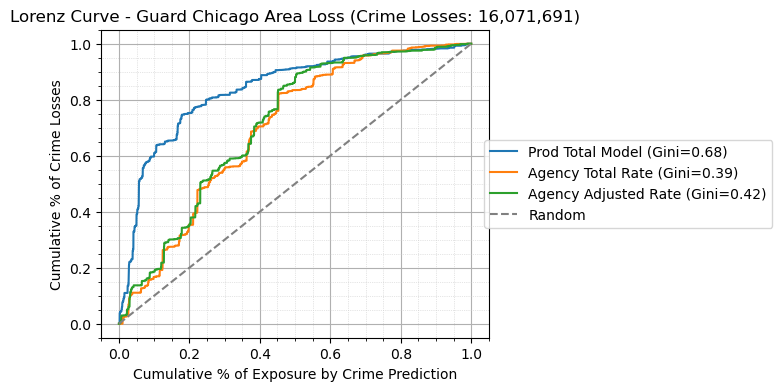

In [80]:
#Plots for Guard Chicago production models
plot_curves('Guard Chicago Area Frequency',
             Guard_eval[Guard_eval['cbsa5']=='16980'],'Crime_Claims','Crime Claims',agency_plots )
plot_curves('Guard Chicago Area Loss',
             Guard_eval[Guard_eval['cbsa5']=='16980'],'Crime_Loss','Crime Losses',agency_plots )

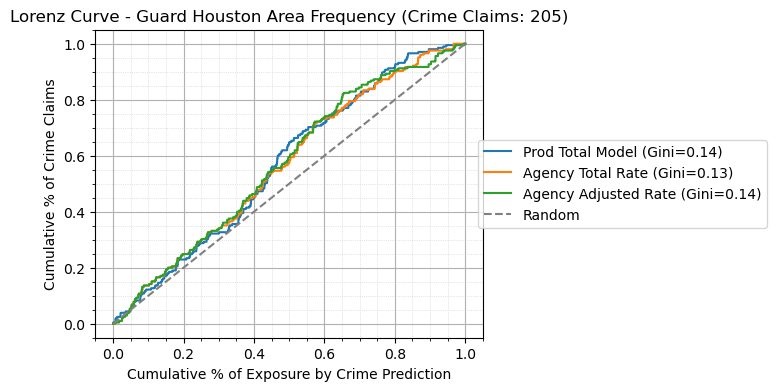

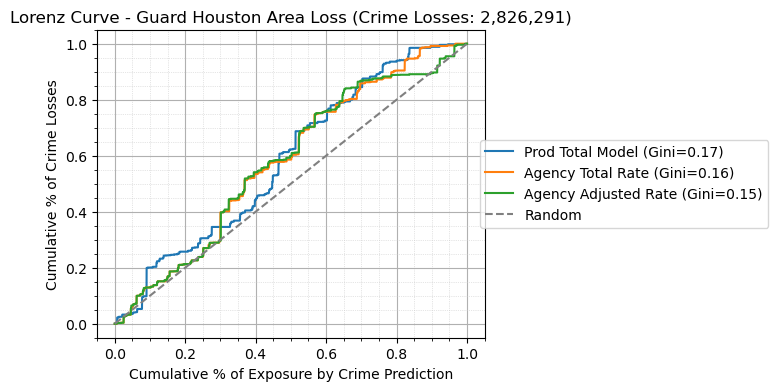

In [81]:
#Plots for Guard Houston models
plot_curves('Guard Houston Area Frequency',
             Guard_eval[Guard_eval['cbsa5']=='26420'],'Crime_Claims','Crime Claims',agency_plots )
plot_curves('Guard Houston Area Loss',
             Guard_eval[Guard_eval['cbsa5']=='26420'],'Crime_Loss','Crime Losses',agency_plots )

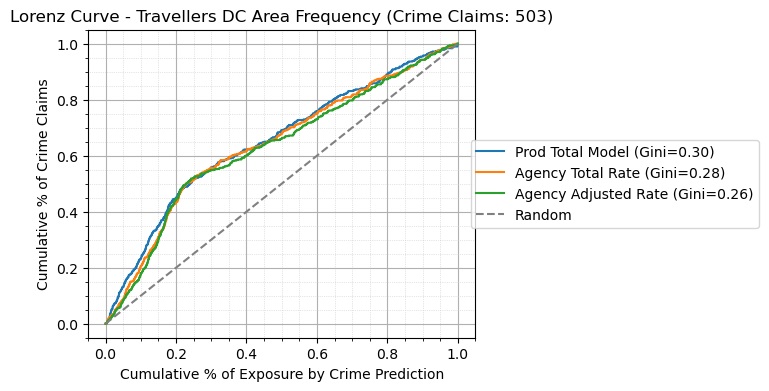

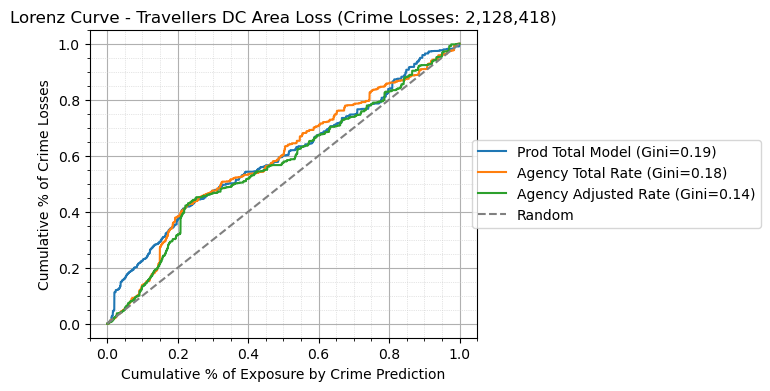

In [83]:
#Plots 
plot_curves('Travellers DC Area Frequency',
             Trav_eval[Trav_eval['cbsa5']=='47900'],'Crime_Claims','Crime Claims',agency_plots )
plot_curves('Travellers DC Area Loss',
             Trav_eval[Trav_eval['cbsa5']=='47900'],'Crime_Loss','Crime Losses',agency_plots )

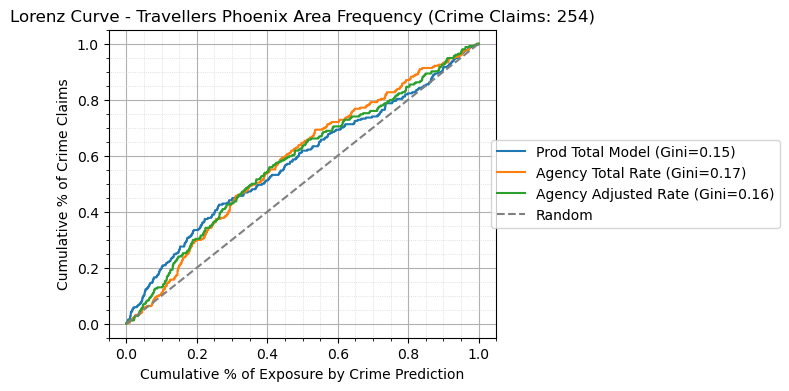

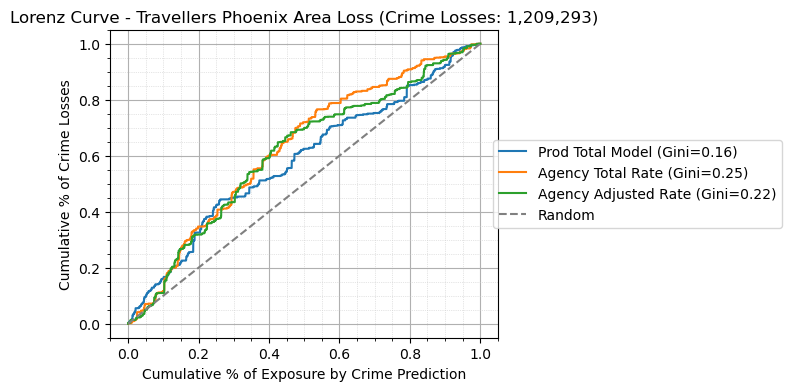

In [ ]:
#Plots 
plot_curves('Travellers Phoenix Area Frequency',
             Trav_eval[Trav_eval['cbsa5']=='38060'],'Crime_Claims','Crime Claims',agency_plots )
plot_curves('Travellers Phoenix Area Loss',
             Trav_eval[Trav_eval['cbsa5']=='38060'],'Crime_Loss','Crime Losses',agency_plots )